# Parameters

In [11]:
import numpy as np
import matplotlib.pyplot as plt

GRID_SIZE = 150
D_O2 = 0.1 
LAMBDA_O2 = 0.044
O2_BOUNDARY = 220.0
O2_HYPOXIA = 10.0
O2_NECROSIS = 1.0
DIFUSION_STEP = 1000  
ORE_LAG_EFFECT = 11.5 * 24

D_TAM = 0.02           
CONC_TAM_MEDIU = 15.0  
LAMBDA_TAM = 0.005     
IC50_TAM = 5.0         
PROB_MOARTE_MAX = 0.02

# Diffusion functions

In [12]:
def difuzie_oxigen(oxigen_vechi, celule):
    oxigen_nou = np.copy(oxigen_vechi)
    O_sus, O_jos = oxigen_vechi[:-2, 1:-1], oxigen_vechi[2:, 1:-1]
    O_stanga, O_dreapta = oxigen_vechi[1:-1, :-2], oxigen_vechi[1:-1, 2:]
    O_centru = oxigen_vechi[1:-1, 1:-1]
    laplacian = O_sus + O_jos + O_stanga + O_dreapta - 4 * O_centru
    consum = np.where(celule[1:-1, 1:-1] > 0, LAMBDA_O2, 0.0) 
    oxigen_nou[1:-1, 1:-1] = O_centru + (D_O2 * laplacian) - consum
    return np.clip(oxigen_nou, 0.0, O2_BOUNDARY)

def difuzie_tamoxifen(tam_vechi, celule):
    tam_nou = np.copy(tam_vechi)
    T_sus, T_jos = tam_vechi[:-2, 1:-1], tam_vechi[2:, 1:-1]
    T_stanga, T_dreapta = tam_vechi[1:-1, :-2], tam_vechi[1:-1, 2:]
    T_centru = tam_vechi[1:-1, 1:-1]
    laplacian = T_sus + T_jos + T_stanga + T_dreapta - 4 * T_centru
    consum = np.where(celule[1:-1, 1:-1] == 1, LAMBDA_TAM, 0.0) 
    tam_nou[1:-1, 1:-1] = T_centru + (D_TAM * laplacian) - consum
    return np.clip(tam_nou, 0.0, CONC_TAM_MEDIU)

# Biology update with treatment

In [13]:
def update_biologie_tratament(celule, oxigen, tamoxifen, ora):
    celule_noi = np.copy(celule)
    PROB_DIV_CURENTA = 0.011 if ora < ORE_LAG_EFFECT else 0.044

    for i in range(1, GRID_SIZE - 1):
        for j in range(1, GRID_SIZE - 1):
            if celule[i, j] == 1: 
                nivel_O2 = oxigen[i, j]
                nivel_TAM = tamoxifen[i, j]
                
                if nivel_O2 <= O2_NECROSIS:
                    celule_noi[i, j] = 2 
                    continue
                if nivel_O2 <= O2_HYPOXIA:
                    continue 
                
                efect_medicament = nivel_TAM / (nivel_TAM + IC50_TAM) 
                
                if np.random.rand() < (PROB_MOARTE_MAX * efect_medicament):
                    celule_noi[i, j] = 2 
                    continue
                
                prob_div_ajustata = PROB_DIV_CURENTA * (1.0 - efect_medicament)
                if np.random.rand() < prob_div_ajustata:
                    vecini_liberi = []
                    if celule[i+1, j] == 0: vecini_liberi.append((i+1, j))
                    if celule[i-1, j] == 0: vecini_liberi.append((i-1, j))
                    if celule[i, j+1] == 0: vecini_liberi.append((i, j+1))
                    if celule[i, j-1] == 0: vecini_liberi.append((i, j-1))
                    
                    if vecini_liberi:
                        nou_i, nou_j = vecini_liberi[np.random.randint(len(vecini_liberi))]
                        celule_noi[nou_i, nou_j] = 1
    return celule_noi

# Main loop

In [14]:
def ruleaza_simulare(ziua_administrare=None, zile_de_simulat=35):
    grid_celule = np.zeros((GRID_SIZE, GRID_SIZE), dtype=int)
    grid_oxigen = np.full((GRID_SIZE, GRID_SIZE), O2_BOUNDARY, dtype=float)
    grid_tamoxifen = np.zeros((GRID_SIZE, GRID_SIZE), dtype=float)
    
    mid = GRID_SIZE // 2
    for i in range(GRID_SIZE):
        for j in range(GRID_SIZE):
            if (i - mid)**2 + (j - mid)**2 <= 11**2: 
                grid_celule[i, j] = 1
                
    ora_administrare = ziua_administrare * 24 if ziua_administrare is not None else float('inf')
    istoric_volum = []
    axa_timp = []
    ore_totale = zile_de_simulat * 24
    
    for ora in range(ore_totale):
        if ora == ora_administrare:
            grid_tamoxifen[:, 0] = grid_tamoxifen[:, -1] = CONC_TAM_MEDIU
            grid_tamoxifen[0, :] = grid_tamoxifen[-1, :] = CONC_TAM_MEDIU
            
        for _ in range(DIFUSION_STEP):
            grid_oxigen = difuzie_oxigen(grid_oxigen, grid_celule)
            if ora >= ora_administrare:
                grid_tamoxifen = difuzie_tamoxifen(grid_tamoxifen, grid_celule)
                
        grid_celule = update_biologie_tratament(grid_celule, grid_oxigen, grid_tamoxifen, ora)
        
        if ora % 24 == 0:
            ziua = ora // 24
            volum = np.sum(grid_celule > 0)
            istoric_volum.append(volum)
            axa_timp.append(ziua)
            # Afișăm un mesaj o dată la 5 zile ca să știm că rulează
            if ziua > 0 and ziua % 5 == 0:
                print(f"S-a calculat ziua {ziua} / {zile_de_simulat}")
            
    istoric_volum.append(np.sum(grid_celule > 0))
    axa_timp.append(zile_de_simulat)
    
    print("Simulare completă!\n")
    return axa_timp, istoric_volum

# Control simulation

In [15]:
print("Simulez Controlul (Fără tratament)")
axa_t, volum_control = ruleaza_simulare(ziua_administrare=None)

Simulez Controlul (Fără tratament)
S-a calculat ziua 5 / 35
S-a calculat ziua 10 / 35
S-a calculat ziua 15 / 35
S-a calculat ziua 20 / 35
S-a calculat ziua 25 / 35
S-a calculat ziua 30 / 35
Simulare completă!



# Early treatment

In [ ]:
print("Simulez Tratamentul Timpuriu (Administrare în Ziua 4)")
_, volum_tratament_timpuriu = ruleaza_simulare(ziua_administrare=4)

Simulez Tratamentul Timpuriu (Administrare în Ziua 4)
S-a calculat ziua 5 / 35
S-a calculat ziua 10 / 35
S-a calculat ziua 15 / 35
S-a calculat ziua 20 / 35
S-a calculat ziua 25 / 35
S-a calculat ziua 30 / 35
Simulare completă!



# Late treatment

In [17]:
print("3. Simulez Tratamentul Târziu (Administrare în Ziua 15)...")
_, volum_tratament_tarziu = ruleaza_simulare(ziua_administrare=15)

3. Simulez Tratamentul Târziu (Administrare în Ziua 15)...
S-a calculat ziua 5 / 35
S-a calculat ziua 10 / 35
S-a calculat ziua 15 / 35
S-a calculat ziua 20 / 35
S-a calculat ziua 25 / 35
S-a calculat ziua 30 / 35
Simulare completă!



# Plotting

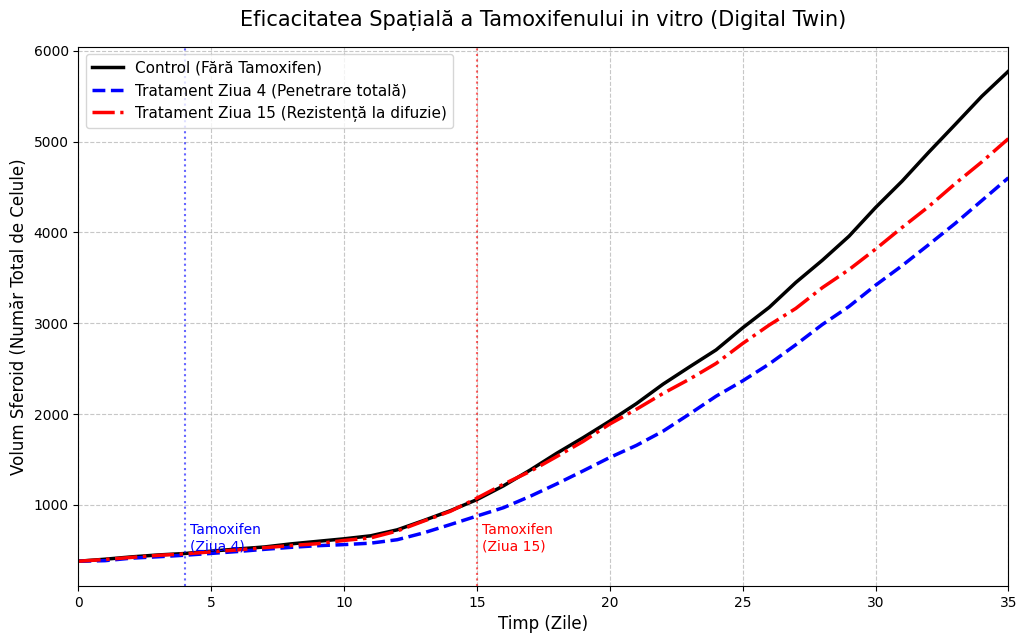

In [18]:
plt.figure(figsize=(12, 7))

plt.plot(axa_t, volum_control, 'k-', linewidth=2.5, label='Control (Fără Tamoxifen)')
plt.plot(axa_t, volum_tratament_timpuriu, 'b--', linewidth=2.5, label='Tratament Ziua 4 (Penetrare totală)')
plt.plot(axa_t, volum_tratament_tarziu, 'r-.', linewidth=2.5, label='Tratament Ziua 15 (Rezistență la difuzie)')

plt.axvline(x=4, color='blue', linestyle=':', alpha=0.6)
plt.axvline(x=15, color='red', linestyle=':', alpha=0.6)
plt.text(4.2, 500, 'Tamoxifen\n(Ziua 4)', color='blue', fontsize=10)
plt.text(15.2, 500, 'Tamoxifen\n(Ziua 15)', color='red', fontsize=10)

plt.title('Eficacitatea Spațială a Tamoxifenului in vitro (Digital Twin)', fontsize=15, pad=15)
plt.xlabel('Timp (Zile)', fontsize=12)
plt.ylabel('Volum Sferoid (Număr Total de Celule)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper left', fontsize=11)
plt.xlim(0, 35)

plt.show()